Quick summary / priorities

Structure: pivot ml_df to a wide country×year table (one row per country-year, columns = indicators).

Basic features: create lag, YoY, YoY_pct, rolling mean/std.

Spikes & dips: detect sudden jumps with threshold + z-score and add binary flags and magnitude features.

Volatility: rolling std of YoY or returns, plus coefficient of variation.

Meta features: region, subregion, income, source coverage, indicator counts.

Cleaning for ML: handle remaining NaNs (row/column thresholds, impute), scale, encode.

Dimensionality & selection: PCA/UMAP, correlation filtering, LASSO/Tree-based importance.

Modeling & evaluation: clustering/unsupervised first (profiles), then supervised tasks if you have labels. Use time-aware CV.

Explainability & diagnostics: SHAP, partial dependence, feature drift checks.

Packaging: pipeline objects, export CSVs/models, reproducible notebook.

In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print(os.getcwd())

/Users/daniehbenotman/Desktop/worldbank_tableau_project/notebooks


In [2]:
os.chdir("/Users/daniehbenotman/Desktop/worldbank_tableau_project")
print("✅ Working directory changed to:", os.getcwd())

✅ Working directory changed to: /Users/daniehbenotman/Desktop/worldbank_tableau_project


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import numpy as np

In [4]:
fe_df = pd.read_csv("data/feature_data.csv")

In [5]:
fe_df.head()

,country_name,year,value,indicator_id,indicator_name,unit_type,source,source_reliable,region,category
0,Algeria,2000,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other
1,Algeria,2001,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other
2,Algeria,2002,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other
3,Algeria,2003,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other
4,Algeria,2004,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other


In [6]:
fe_df["indicator_name"].nunique()


42

In [7]:
fe_df["country_name"].nunique()

18

In [8]:
fe_df["year"].min()

2000

In [9]:
fe_df["year"].max()

2023

In [10]:
fe_df["value"].isna().sum()

0

## Feature Engineering Prep

In [11]:
fe_df['unit_type'].unique()

array(['Binary (1/0)', 'Rate per 1,000', 'Percent (%)', 'Currency (US$)',
       'Years', 'Rate per 100,000', 'Count', 'Index / Score'],
      dtype=object)

In [15]:
fe_df['val_num'] = pd.to_numeric(fe_df['value'], errors='coerce')

# identify groups by unit_type
binary_inds = fe_df.loc[fe_df['unit_type'] == "Binary (1/0)", 'indicator_name'].unique().tolist()

percent_inds = fe_df.loc[fe_df['unit_type'] == "Percent (%)", 'indicator_name'].unique().tolist()

index_inds = fe_df.loc[fe_df['unit_type'] == "Index / Score", 'indicator_name'].unique().tolist()

rate_inds = fe_df.loc[fe_df['unit_type'].isin(["Rate per 1,000", "Rate per 100,000"]), 
                      'indicator_name'].unique().tolist()

count_inds = fe_df.loc[fe_df['unit_type'].isin(["Count", "Years", "Currency (US$)"]), 
                       'indicator_name'].unique().tolist()


print("Binary indicators:", len(binary_inds))
print("Percent indicators:", len(percent_inds))
print("Index/Score indicators:", len(index_inds))
print("Rate indicators:", len(rate_inds))
print("Count indicators:", len(count_inds))



Binary indicators: 15
Percent indicators: 9
Index/Score indicators: 10
Rate indicators: 4
Count indicators: 4


In [16]:
fe_df = fe_df.sort_values(['country_name','indicator_name','year']).reset_index(drop=True)


## 1. YOY Change

In [18]:

# Indicators where pct change / growth is NOT sensible
skip_pct_change = set(binary_inds) | set(index_inds)

# 1) YoY absolute change (works for numeric series; binary will get diffs 0/±1 naturally)
fe_df['yoy_change'] = fe_df.groupby(
    ['country_name','indicator_name'])['val_num'].transform(lambda s: s.diff())

# 2) YoY percent change (skip where not sensible)
fe_df['yoy_pct_change'] = fe_df.groupby(
    ['country_name','indicator_name'])['val_num'].transform(lambda s: s.pct_change()*100)


# 3) Null-out pct change where unit_type indicates it's not meaningful
fe_df.loc[fe_df['indicator_name'].isin(skip_pct_change), 'yoy_pct_change'] = np.nan

# 4) Replace inf/-inf (from division by zero) with NaN
fe_df['yoy_pct_change'].replace([np.inf, -np.inf], np.nan, inplace=True)

# 5) A small helper column showing where pct change is available
fe_df['yoy_pct_exists'] = fe_df['yoy_pct_change'].notna()

# --- Sanity summary (print) ---
print("TOTAL ROWS:", len(fe_df))
print("YoY absolute change NaN proportion:", fe_df['yoy_change'].isna().mean())
print("YoY % change NaN proportion:",fe_df['yoy_pct_change'].isna().mean())
print("\nTop indicators by YoY % change missingness:")
print(fe_df.groupby('indicator_name')['yoy_pct_change'].apply(lambda s: s.isna().mean()).sort_values(ascending=False).head(10))



TOTAL ROWS: 18144
YoY absolute change NaN proportion: 0.041666666666666664
YoY % change NaN proportion: 0.6181106701940036

Top indicators by YoY % change missingness:
indicator_name
A woman can apply for a passport in the same way as a man (1=yes; 0=no)        1.0
A woman has the same rights to remarry as a man (1=yes; 0=no)                  1.0
Women, Business and the Law: Pension Indicator Score (scale 1-100)             1.0
Women, Business and the Law: Pay Indicator Score (scale 1-100)                 1.0
Women, Business and the Law: Parenthood Indicator Score (scale 1-100)          1.0
Women, Business and the Law: Mobility Indicator Score (scale 1-100)            1.0
Women, Business and the Law: Marriage Indicator Score (scale 1-100)            1.0
Women, Business and the Law: Entrepreneurship Indicator Score (scale 1-100)    1.0
Women, Business and the Law: Assets Indicator Score (scale 1-100)              1.0
Women Business and the Law Index Score (scale 1-100)                  

/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_12946/2347005083.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  fe_df['yoy_pct_change'].replace([np.inf, -np.inf], np.nan, inplace=True)


In [19]:
# Example spot-check: show first 6 rows for a numeric indicator and a binary indicator
sample_numeric = fe_df.loc[~fe_df['indicator_name'].isin(list(skip_pct_change)), 'indicator_name'].value_counts().index[0]
sample_binary  = next(iter(binary_inds)) if len(binary_inds)>0 else None

print("\nSample numeric indicator for checks:", sample_numeric)
display(fe_df.loc[fe_df['indicator_name']==sample_numeric].head(6))

if sample_binary:
    print("\nSample binary indicator for checks:", sample_binary)
    display(fe_df.loc[fe_df['indicator_name']==sample_binary].head(6))



Sample numeric indicator for checks: Adolescent fertility rate (births per 1,000 women ages 15-19)


,country_name,year,value,indicator_id,indicator_name,unit_type,source,source_reliable,region,category,val_num,yoy_change,yoy_pct_change,yoy_pct_exists
336,Algeria,2000,8.658,SP.ADO.TFRT,"Adolescent fertility rate (births per 1,000 wo...","Rate per 1,000",WHO,high,North Africa,Health,8.658,NaN,NaN,False
337,Algeria,2001,8.065,SP.ADO.TFRT,"Adolescent fertility rate (births per 1,000 wo...","Rate per 1,000",WHO,high,North Africa,Health,8.065,-0.593,-6.849157,True
338,Algeria,2002,7.740,SP.ADO.TFRT,"Adolescent fertility rate (births per 1,000 wo...","Rate per 1,000",WHO,high,North Africa,Health,7.740,-0.325,-4.029758,True
339,Algeria,2003,7.727,SP.ADO.TFRT,"Adolescent fertility rate (births per 1,000 wo...","Rate per 1,000",WHO,high,North Africa,Health,7.727,-0.013,-0.167959,True
340,Algeria,2004,7.789,SP.ADO.TFRT,"Adolescent fertility rate (births per 1,000 wo...","Rate per 1,000",WHO,high,North Africa,Health,7.789,0.062,0.802381,True
341,Algeria,2005,7.870,SP.ADO.TFRT,"Adolescent fertility rate (births per 1,000 wo...","Rate per 1,000",WHO,high,North Africa,Health,7.870,0.081,1.039928,True



Sample binary indicator for checks: A woman can apply for a passport in the same way as a man (1=yes; 0=no)


,country_name,year,value,indicator_id,indicator_name,unit_type,source,source_reliable,region,category,val_num,yoy_change,yoy_pct_change,yoy_pct_exists
0,Algeria,2000,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other,0.0,NaN,NaN,False
1,Algeria,2001,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other,0.0,0.0,NaN,False
2,Algeria,2002,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other,0.0,0.0,NaN,False
3,Algeria,2003,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other,0.0,0.0,NaN,False
4,Algeria,2004,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other,0.0,0.0,NaN,False
5,Algeria,2005,0.0,SG.APL.PSPT.EQ,A woman can apply for a passport in the same w...,Binary (1/0),WHO,high,North Africa,Other,0.0,0.0,NaN,False


## 2. Rolling Means and Rolling STD (3y and 5y)

In [21]:
rolling_windows = [3, 5]

# ensure val_num exists
if 'val_num' not in fe_df.columns:
    fe_df['val_num'] = pd.to_numeric(fe_df['value'], errors='coerce')
    

# prepare binary set (we'll zero/NA-out std for these)
binary_inds = set(fe_df.loc[fe_df['unit_type'] == "Binary (1/0)", 'indicator_name'].unique())


# compute rolling stats
for w in rolling_windows:
    mean_col = f'rolling_mean_{w}y'
    std_col  = f'rolling_std_{w}y'

    # rolling mean (min_periods=1 so the first years still get a mean)
    fe_df[mean_col] = (
        fe_df.groupby(['country_name','indicator_name'])['val_num']
             .transform(lambda s: s.rolling(window=w, min_periods=1).mean())
    )

    # rolling std (min_periods=2 to avoid std of single value)
    fe_df[std_col] = (
        fe_df.groupby(['country_name','indicator_name'])['val_num']
             .transform(lambda s: s.rolling(window=w, min_periods=2).std())
    )
    
    # Null-out rolling std for binary indicators (not meaningful)
std_cols = [c for c in fe_df.columns if c.startswith('rolling_std_')]
mask_binary = fe_df['indicator_name'].isin(binary_inds)
fe_df.loc[mask_binary, std_cols] = np.nan



# Replace any np.inf/-np.inf if appeared (safer assignment)
for c in std_cols + [f'rolling_mean_{w}y' for w in rolling_windows]:
    fe_df[c] = fe_df[c].replace([np.inf, -np.inf], np.nan)


# Sanity summaries
print("Rolling columns created:", [c for c in fe_df.columns if 'rolling_' in c])
print("\nProportion of NaNs in rolling std 3y by unit_type:")
print( fe_df.groupby('unit_type')['rolling_std_3y'].apply(lambda s: s.isna().mean()).sort_values() )

# Spot checks: numeric indicator (example) and a binary
# pick a numeric indicator (first one that's not binary/index)
sample_numeric = fe_df.loc[~fe_df['indicator_name'].isin(list(binary_inds)), 'indicator_name'].value_counts().index[0]
sample_binary  = next(iter(binary_inds)) if len(binary_inds)>0 else None

print("\nSample numeric indicator:", sample_numeric)
display( fe_df.loc[fe_df['indicator_name']==sample_numeric].head(8)[['country_name','year','val_num','rolling_mean_3y','rolling_std_3y','rolling_mean_5y','rolling_std_5y']] )

if sample_binary:
    print("\nSample binary indicator (stds should be NaN):", sample_binary)
    display( fe_df.loc[fe_df['indicator_name']==sample_binary].head(8)[['country_name','year','val_num','rolling_mean_3y','rolling_std_3y']] )


Rolling columns created: ['rolling_mean_3y', 'rolling_std_3y', 'rolling_mean_5y', 'rolling_std_5y']

Proportion of NaNs in rolling std 3y by unit_type:
unit_type
Count               0.041667
Currency (US$)      0.041667
Index / Score       0.041667
Percent (%)         0.041667
Rate per 1,000      0.041667
Rate per 100,000    0.041667
Years               0.041667
Binary (1/0)        1.000000
Name: rolling_std_3y, dtype: float64

Sample numeric indicator: Adolescent fertility rate (births per 1,000 women ages 15-19)


,country_name,year,val_num,rolling_mean_3y,rolling_std_3y,rolling_mean_5y,rolling_std_5y
336,Algeria,2000,8.658,8.658000,NaN,8.658000,NaN
337,Algeria,2001,8.065,8.361500,0.419314,8.361500,0.419314
338,Algeria,2002,7.740,8.154333,0.465474,8.154333,0.465474
339,Algeria,2003,7.727,7.844000,0.191502,8.047500,0.436002
340,Algeria,2004,7.789,7.752000,0.032696,7.995800,0.394889
341,Algeria,2005,7.870,7.795333,0.071710,7.838200,0.138635
342,Algeria,2006,8.403,8.020667,0.333578,7.905800,0.283545
343,Algeria,2007,8.795,8.356000,0.464288,8.116800,0.464266



Sample binary indicator (stds should be NaN): A woman can apply for a passport in the same way as a man (1=yes; 0=no)


,country_name,year,val_num,rolling_mean_3y,rolling_std_3y
0,Algeria,2000,0.0,0.0,NaN
1,Algeria,2001,0.0,0.0,NaN
2,Algeria,2002,0.0,0.0,NaN
3,Algeria,2003,0.0,0.0,NaN
4,Algeria,2004,0.0,0.0,NaN
5,Algeria,2005,0.0,0.0,NaN
6,Algeria,2006,0.0,0.0,NaN
7,Algeria,2007,0.0,0.0,NaN


## 3. Compound Annual Growth Rate

In [22]:
print("\n[Step 3] Computing CAGR...")

fe_df = fe_df.sort_values(["country_name", "indicator_name", "year"])

def calc_cagr(group):
    """
    Computes CAGR for a single country-indicator group.
    Returns a series of the same length for assignment.
    """
    
    # Skip binary indicators — CAGR does not apply
    if group["unit_type"].iloc[0] == "Binary (1/0)":
        return pd.Series([np.nan] * len(group), index=group.index)
    
    
    group = group.sort_values("year")
    
    if len(group) < 2:
        # Not enough years to compute growth
        return pd.Series([np.nan] * len(group), index=group.index)

    start_val = group["val_num"].iloc[0]
    start_year = group["year"].iloc[0]
    
    # Avoid division by zero for indicators starting at 0
    if start_val == 0:
        return pd.Series([np.nan] * len(group), index=group.index)

    years_elapsed = group["year"] - start_year
    
     # Compute CAGR
    with np.errstate(divide='ignore', invalid='ignore'):
        cagr = ((group["val_num"] / start_val) ** (1 / years_elapsed)) - 1
        
     # First year always NaN because no growth yet
    cagr.iloc[0] = np.nan
    
    return cagr * 100  # convert to percent

# Apply groupby
fe_df["cagr"] = fe_df.groupby(
    ["country_name", "indicator_name"],
    group_keys=False
).apply(calc_cagr)

print("CAGR added successfully!")
print("CAGR NaN proportion:", fe_df["cagr"].isna().mean())

    
    


[Step 3] Computing CAGR...
CAGR added successfully!
CAGR NaN proportion: 0.45717592592592593


/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_12946/805232792.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(calc_cagr)


## 4. Shock Detection (Spikes and Dips)

In [ ]:
print("\n[Step 4] Detecting Spikes...")



In [23]:
def detect_spikes(group, threshold=2.0):
    vals = group['val_num'].values
    if len(vals) < 3:
        return pd.Series([0]*len(vals), index=group.index)

    mean = np.mean(vals)
    std = np.std(vals)

    if std == 0:
        return pd.Series([0]*len(vals), index=group.index)

    z = (vals - mean) / std
    spikes = (z > threshold).astype(int)

    return pd.Series(spikes, index=group.index)

fe_df['spike'] = fe_df.groupby(["country_name", "indicator_name"]).apply(
    detect_spikes
).reset_index(level=[0,1], drop=True)

print("Spike detection complete!")
print("Spike counts:", fe_df['spike'].sum())



Spike detection complete!
Spike counts: 327


/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_12946/592226083.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fe_df['spike'] = fe_df.groupby(["country_name", "indicator_name"]).apply(


In [24]:
print("\n[Step 5] Detecting Dips...")

def detect_dips(group, threshold=2.0):
    vals = group['val_num'].values
    if len(vals) < 3:
        return pd.Series([0]*len(vals), index=group.index)

    mean = np.mean(vals)
    std = np.std(vals)

    if std == 0:
        return pd.Series([0]*len(vals), index=group.index)

    z = (vals - mean) / std
    dips = (z < -threshold).astype(int)

    return pd.Series(dips, index=group.index)

fe_df['dip'] = fe_df.groupby(["country_name", "indicator_name"]).apply(
    detect_dips
).reset_index(level=[0,1], drop=True)

print("Dip detection complete!")
print("Dip counts:", fe_df['dip'].sum())



[Step 5] Detecting Dips...
Dip detection complete!
Dip counts: 118


/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_12946/3314611786.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fe_df['dip'] = fe_df.groupby(["country_name", "indicator_name"]).apply(


In [25]:
fe_df[['spike', 'dip']].sum()


spike    327
dip      118
dtype: int64

In [26]:
sample = fe_df[fe_df['indicator_name']=="Adolescent fertility rate (births per 1,000 women ages 15-19)"]
sample[sample['country_name']=="Iraq"][['year','val_num','spike','dip']]


,year,val_num,spike,dip
4368,2000,59.280,0,0
4369,2001,58.997,0,0
4370,2002,60.846,0,0
4371,2003,64.393,0,0
4372,2004,69.568,0,0
4373,2005,73.213,0,0
4374,2006,78.229,0,0
4375,2007,79.181,0,0
4376,2008,79.068,0,0
4377,2009,80.796,0,0


In [28]:
fe_df[fe_df['indicator_name']=="Vulnerable employment, female (% of female employment) (modeled ILO estimate)"]


,country_name,year,value,indicator_id,indicator_name,unit_type,source,source_reliable,region,category,...,yoy_change,yoy_pct_change,yoy_pct_exists,rolling_mean_3y,rolling_std_3y,rolling_mean_5y,rolling_std_5y,cagr,spike,dip
744,Algeria,2000,38.079957,SL.EMP.VULN.FE.ZS,"Vulnerable employment, female (% of female emp...",Percent (%),WHO,high,North Africa,Labor,...,NaN,NaN,False,38.079957,NaN,38.079957,NaN,NaN,1,0
745,Algeria,2001,37.510160,SL.EMP.VULN.FE.ZS,"Vulnerable employment, female (% of female emp...",Percent (%),WHO,high,North Africa,Labor,...,-0.569797,-1.496316,True,37.795059,0.402907,37.795059,0.402907,-1.496316,1,0
746,Algeria,2002,34.800292,SL.EMP.VULN.FE.ZS,"Vulnerable employment, female (% of female emp...",Percent (%),WHO,high,North Africa,Labor,...,-2.709868,-7.224358,True,36.796803,1.752344,36.796803,1.752344,-4.403230,0,0
747,Algeria,2003,32.155629,SL.EMP.VULN.FE.ZS,"Vulnerable employment, female (% of female emp...",Percent (%),WHO,high,North Africa,Labor,...,-2.644663,-7.599543,True,34.822027,2.677332,35.636510,2.726218,-5.480768,0,0
748,Algeria,2004,30.525034,SL.EMP.VULN.FE.ZS,"Vulnerable employment, female (% of female emp...",Percent (%),WHO,high,North Africa,Labor,...,-1.630594,-5.070945,True,32.493652,2.157580,34.614215,3.286280,-5.378478,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17899,"Yemen, Rep.",2019,65.493046,SL.EMP.VULN.FE.ZS,"Vulnerable employment, female (% of female emp...",Percent (%),WHO,high,Other,Labor,...,0.085903,0.131336,True,65.384295,0.121793,65.254694,0.197745,0.211576,0,0
17900,"Yemen, Rep.",2020,65.236183,SL.EMP.VULN.FE.ZS,"Vulnerable employment, female (% of female emp...",Percent (%),WHO,high,Other,Labor,...,-0.256863,-0.392199,True,65.378790,0.130758,65.293798,0.160700,0.181301,0,0
17901,"Yemen, Rep.",2021,64.382262,SL.EMP.VULN.FE.ZS,"Vulnerable employment, female (% of female emp...",Percent (%),WHO,high,Other,Labor,...,-0.853921,-1.308968,True,65.037163,0.581521,65.154266,0.444721,0.109828,0,0
17902,"Yemen, Rep.",2022,63.875061,SL.EMP.VULN.FE.ZS,"Vulnerable employment, female (% of female emp...",Percent (%),WHO,high,Other,Labor,...,-0.507201,-0.787796,True,64.497835,0.687881,64.878739,0.713829,0.068851,0,0


## 5. Outlier Detection (IQR)

In [29]:
print("\n[Step 5] Flagging outliers with IQR method...")

def flag_outliers(group):
    values = group['val_num'].values
    
    # If the series is constant or too short → no outliers
    if len(values) < 4 or np.std(values) == 0:
        return pd.Series([0] * len(values), index=group.index)
    
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outliers = ((values < lower) | (values > upper)).astype(int)
    return pd.Series(outliers, index=group.index)

fe_df['outlier'] = fe_df.groupby(
    ['country_name', 'indicator_name']
).apply(flag_outliers).reset_index(level=[0, 1], drop=True)

print("Outlier count:", fe_df['outlier'].sum())
print("Outlier proportion:", fe_df['outlier'].mean())



[Step 5] Flagging outliers with IQR method...
Outlier count: 713
Outlier proportion: 0.03929673721340388


/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_12946/4200339678.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(flag_outliers).reset_index(level=[0, 1], drop=True)


## 6. Trend Features

#### 6.1  Trend Slope (Linear Regression Slope)

In [30]:
print("\n[Step 6.1] Computing trend slopes...")

from scipy import stats

def calc_slope(group):
    group = group.sort_values('year')
    if len(group) < 2:
        return pd.Series([np.nan] * len(group), index=group.index)
    
    x = group['year'].values
    y = group['val_num'].values
    
    slope, _, _, _, _ = stats.linregress(x, y)
    return pd.Series([slope] * len(group), index=group.index)

fe_df['trend_slope'] = fe_df.groupby(
    ['country_name', 'indicator_name']
).apply(calc_slope).reset_index(level=[0, 1], drop=True)

print("Trend slope NaN proportion:", fe_df['trend_slope'].isna().mean())


[Step 6.1] Computing trend slopes...
Trend slope NaN proportion: 0.0


/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_12946/2501289608.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(calc_slope).reset_index(level=[0, 1], drop=True)


#### 6.2 Coefficient of Variation (CV = std / mean)

In [31]:
print("\n[Step 6.2] Computing coefficient of variation...")

def calc_cv(group):
    mean = group['val_num'].mean()
    std = group['val_num'].std()
    
    if mean == 0 or pd.isna(mean):
        cv = np.nan
    else:
        cv = (std / abs(mean)) * 100
    
    return pd.Series([cv] * len(group), index=group.index)

fe_df['coef_variation'] = fe_df.groupby(
    ['country_name', 'indicator_name']
).apply(calc_cv).reset_index(level=[0, 1], drop=True)

print("CV NaN proportion:", fe_df['coef_variation'].isna().mean())



[Step 6.2] Computing coefficient of variation...
CV NaN proportion: 0.17328042328042328


/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_12946/801461636.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ).apply(calc_cv).reset_index(level=[0, 1], drop=True)


#### 6.3 Momentum (Acceleration of change)

In [32]:
print("\n[Step 6.3] Computing momentum...")

fe_df = fe_df.sort_values(['country_name', 'indicator_name', 'year'])

# First derivative
roc = fe_df.groupby(
    ['country_name', 'indicator_name']
)['val_num'].pct_change()

# Second derivative (momentum)
fe_df['momentum'] = roc.groupby(
    [fe_df['country_name'], fe_df['indicator_name']]
).diff()

print("Momentum NaN proportion:", fe_df['momentum'].isna().mean())



[Step 6.3] Computing momentum...
Momentum NaN proportion: 0.31101190476190477


## 7. Regional Deviation Features

In [33]:
print("\n[Step 7] Computing regional deviation features...")

# Regional mean for each indicator-year-region
regional_means = fe_df.groupby(
    ['region', 'indicator_name', 'year']
)['val_num'].transform('mean')

fe_df['regional_deviation'] = fe_df['val_num'] - regional_means

# Regional standard deviation
regional_stds = fe_df.groupby(
    ['region', 'indicator_name', 'year']
)['val_num'].transform('std')

# Standardized deviation
fe_df['regional_deviation_std'] = np.where(
    regional_stds != 0,
    fe_df['regional_deviation'] / regional_stds,
    0
)

print("Regional deviation NaN proportion:", fe_df['regional_deviation'].isna().mean())
print("Regional deviation std proportion:", fe_df['regional_deviation_std'].isna().mean())



[Step 7] Computing regional deviation features...
Regional deviation NaN proportion: 0.0
Regional deviation std proportion: 0.0


## Attach Events to Your Feature Dataset

In [34]:
from models.events import (
    EVENT_MAPPING,
    SHORT_EVENTS,
    MAJOR_EVENTS,
    COUNTRY_YEAR_EVENTS
)

In [35]:
def map_global_event(year):
    if year in MAJOR_EVENTS:
        return MAJOR_EVENTS[year]
    if year in EVENT_MAPPING:
        return EVENT_MAPPING[year]
    if year in SHORT_EVENTS:
        return SHORT_EVENTS[year]
    return None


def map_country_event(row):
    key = (row['country_name'], row['year'])
    # Match country-year specific first
    if key in COUNTRY_YEAR_EVENTS:
        return COUNTRY_YEAR_EVENTS[key]
    # Match "All" events
    if ('All', row['year']) in COUNTRY_YEAR_EVENTS:
        return COUNTRY_YEAR_EVENTS[('All', row['year'])]
    return None


fe_df['event_global'] = fe_df['year'].apply(map_global_event)
fe_df['event_country'] = fe_df.apply(map_country_event, axis=1)

print("Global events mapped:", fe_df['event_global'].notna().sum())
print("Country events mapped:", fe_df['event_country'].notna().sum())


Global events mapped: 15120
Country events mapped: 2562


## Feature-by-Feature Visual Analysis Plan

In [36]:
def plot_indicator(country, indicator):
    temp = fe_df[(fe_df.country_name==country) &
                 (fe_df.indicator_name==indicator)]
    
    plt.figure(figsize=(12,6))
    
    plt.plot(temp.year, temp.val_num, label="Value", marker="o")
    plt.plot(temp.year, temp.rolling_mean_3y, label="3Y Rolling", linewidth=2)
    
    # event lines
    for y, ev in temp[['year', 'event_global']].dropna().values:
        plt.axvline(y, color='red', alpha=.4)
        plt.text(y, temp.val_num.max(), ev, rotation=90)

    plt.title(f"{country} — {indicator}")
    plt.legend()
    plt.show()
    
    

### Plot A — Raw Values + Rolling Means (3Y/5Y) + Event Lines

Shows long-term trends + structural patterns + the effect of reforms or crises.

In [38]:
wbl_df = fe_df[fe_df["category"] == "WBL"].copy()
print("WBL rows:", len(wbl_df))
print("WBL indicators:", wbl_df["indicator_name"].nunique())
wbl_df.head()


WBL rows: 3456
WBL indicators: 8


,country_name,year,value,indicator_id,indicator_name,unit_type,source,source_reliable,region,category,...,spike,dip,outlier,trend_slope,coef_variation,momentum,regional_deviation,regional_deviation_std,event_global,event_country
792,Algeria,2000,40.625,SG.LAW.INDX,Women Business and the Law Index Score (scale ...,Index / Score,WHO,high,North Africa,WBL,...,0,0,1,0.73288,12.297369,NaN,-1.250,-0.134080,None,None
793,Algeria,2001,40.625,SG.LAW.INDX,Women Business and the Law Index Score (scale ...,Index / Score,WHO,high,North Africa,WBL,...,0,0,1,0.73288,12.297369,NaN,-1.875,-0.223607,9/11 Attacks,None
794,Algeria,2002,40.625,SG.LAW.INDX,Women Business and the Law Index Score (scale ...,Index / Score,WHO,high,North Africa,WBL,...,0,0,1,0.73288,12.297369,0.0,-1.875,-0.223607,None,None
795,Algeria,2003,40.625,SG.LAW.INDX,Women Business and the Law Index Score (scale ...,Index / Score,WHO,high,North Africa,WBL,...,0,0,1,0.73288,12.297369,0.0,-3.000,-0.423109,Iraq War Begins,None
796,Algeria,2004,40.625,SG.LAW.INDX,Women Business and the Law Index Score (scale ...,Index / Score,WHO,high,North Africa,WBL,...,0,0,1,0.73288,12.297369,0.0,-8.250,-0.586406,Morocco Family Code Reform; Free Trade with US...,None


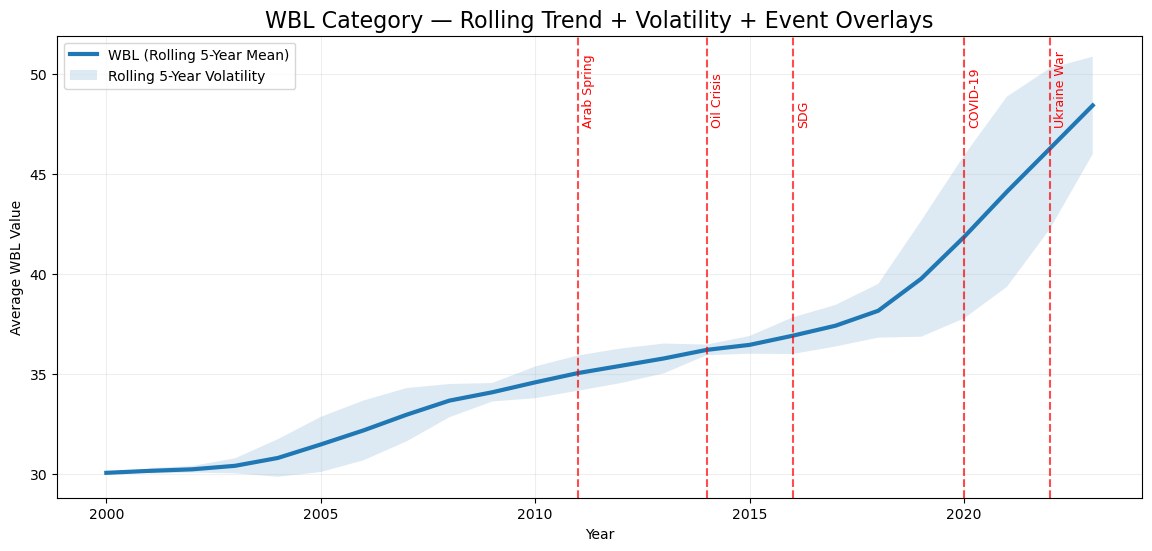

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make the category-level series
wbl_summary = (
    wbl_df.groupby("year")["val_num"]
    .mean()
    .reset_index()
)

# Rolling volatility (standard deviation)
wbl_summary["rolling_mean_5y"] = wbl_summary["val_num"].rolling(5, min_periods=1).mean()
wbl_summary["rolling_std_5y"] = wbl_summary["val_num"].rolling(5, min_periods=1).std()

# Plot
plt.figure(figsize=(14,6))

# Rolling mean line
plt.plot(
    wbl_summary["year"],
    wbl_summary["rolling_mean_5y"],
    linewidth=3,
    label="WBL (Rolling 5-Year Mean)"
)

# Volatility shaded area
plt.fill_between(
    wbl_summary["year"],
    wbl_summary["rolling_mean_5y"] - wbl_summary["rolling_std_5y"],
    wbl_summary["rolling_mean_5y"] + wbl_summary["rolling_std_5y"],
    alpha=0.15,
    label="Rolling 5-Year Volatility"
)

# Add major event markers
events = {
    2011: "Arab Spring",
    2014: "Oil Crisis",
    2016: "SDG",
    2020: "COVID-19",
    2022: "Ukraine War"
}

for year, label in events.items():
    if year in wbl_summary["year"].values:
        plt.axvline(x=year, color="red", linestyle="--", alpha=0.7)
        plt.text(year + 0.1, wbl_summary["rolling_mean_5y"].max()*0.98,
                 label, rotation=90, color="red", fontsize=9)

plt.title("WBL Category — Rolling Trend + Volatility + Event Overlays", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Average WBL Value")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


📊 WBL Category — Indicator-Level Comparison
Visualization Set:

Panel 1: Rolling mean (5-year) trends per indicator

Panel 2: Rolling volatility (std) per indicator

Panel 3: YoY percentage change per indicator

Panel 4: Spike frequency per indicator (bar chart)



#### PLOT SET 1 — Rolling Mean Trend for Each WBL Indicator

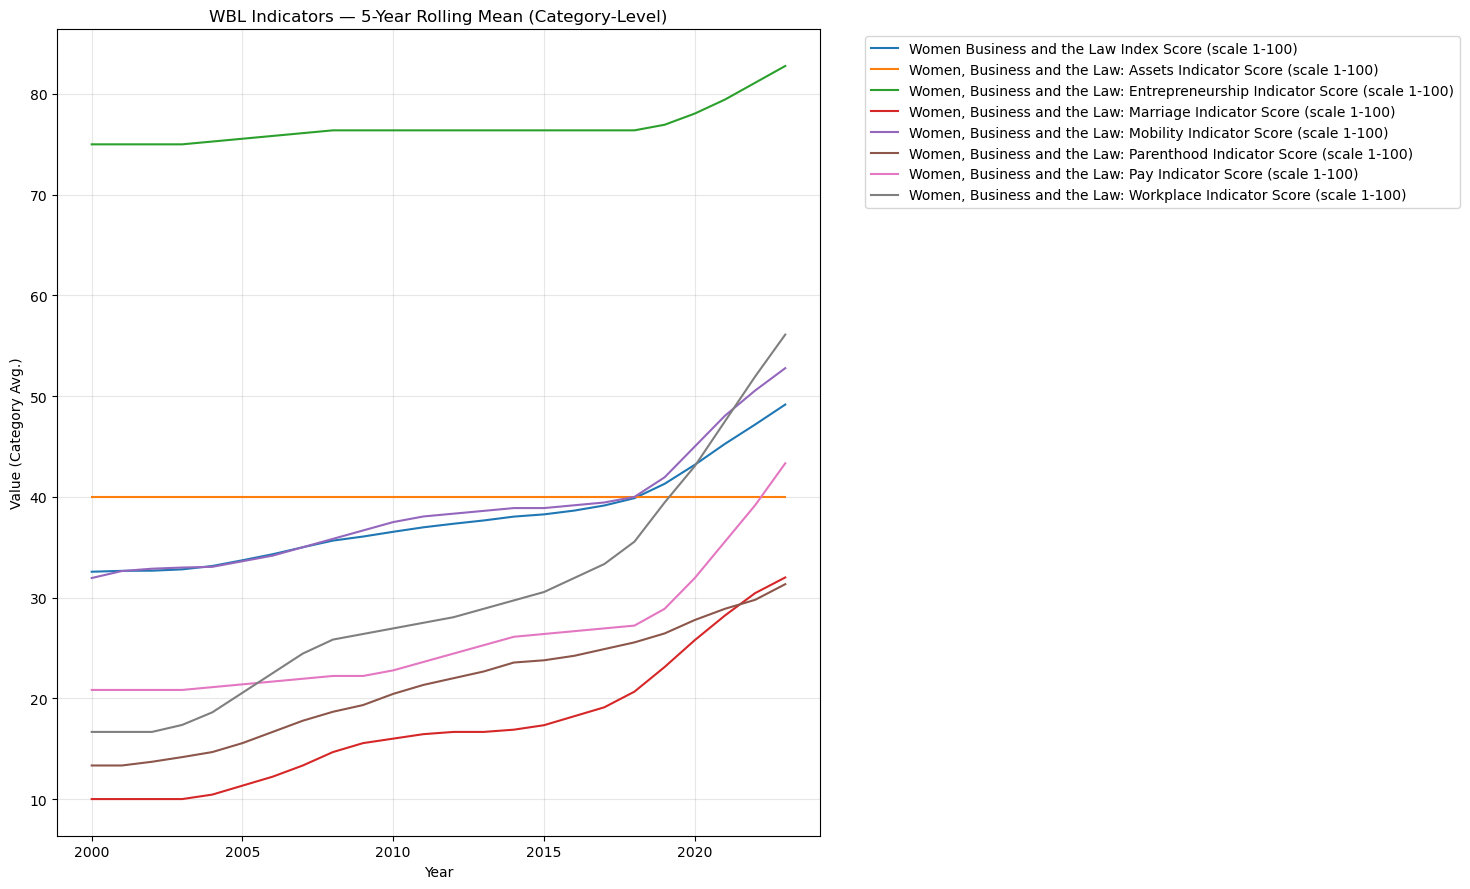

In [41]:
indicators = wbl_df["indicator_name"].unique()

plt.figure(figsize=(15, 9))

for ind in indicators:
    temp = (wbl_df[wbl_df["indicator_name"] == ind]
            .groupby("year")["val_num"]
            .mean()
            .rolling(5, min_periods=1)
            .mean()
            .reset_index())
    
    plt.plot(temp["year"], temp["val_num"], label=ind)

plt.title("WBL Indicators — 5-Year Rolling Mean (Category-Level)")
plt.xlabel("Year")
plt.ylabel("Value (Category Avg.)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### PLOT SET 2 — Rolling Volatility for Each Indicator

Helps you identify:

Which indicators change frequently

Which are legally “frozen” (marriage laws, passports)

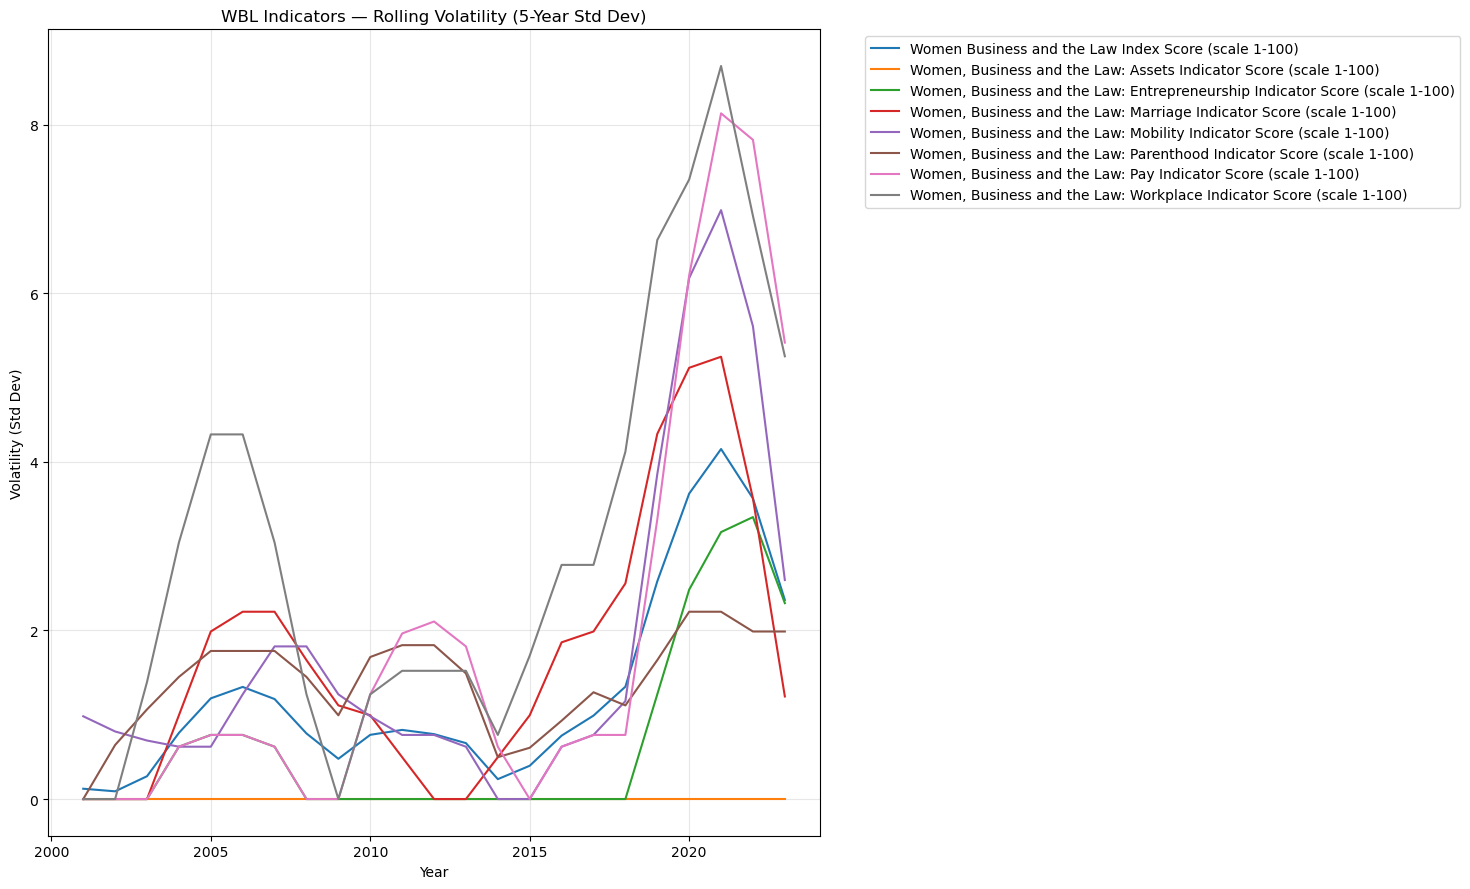

In [42]:
plt.figure(figsize=(15, 9))

for ind in indicators:
    temp = (wbl_df[wbl_df["indicator_name"] == ind]
            .groupby("year")["val_num"]
            .mean()
            .rolling(5, min_periods=2)
            .std()
            .reset_index())
    
    plt.plot(temp["year"], temp["val_num"], label=ind)

plt.title("WBL Indicators — Rolling Volatility (5-Year Std Dev)")
plt.xlabel("Year")
plt.ylabel("Volatility (Std Dev)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### PLOT SET 3 — YoY % Change Comparison

This shows:

sudden legal reforms

structural jumps

politically driven shocks

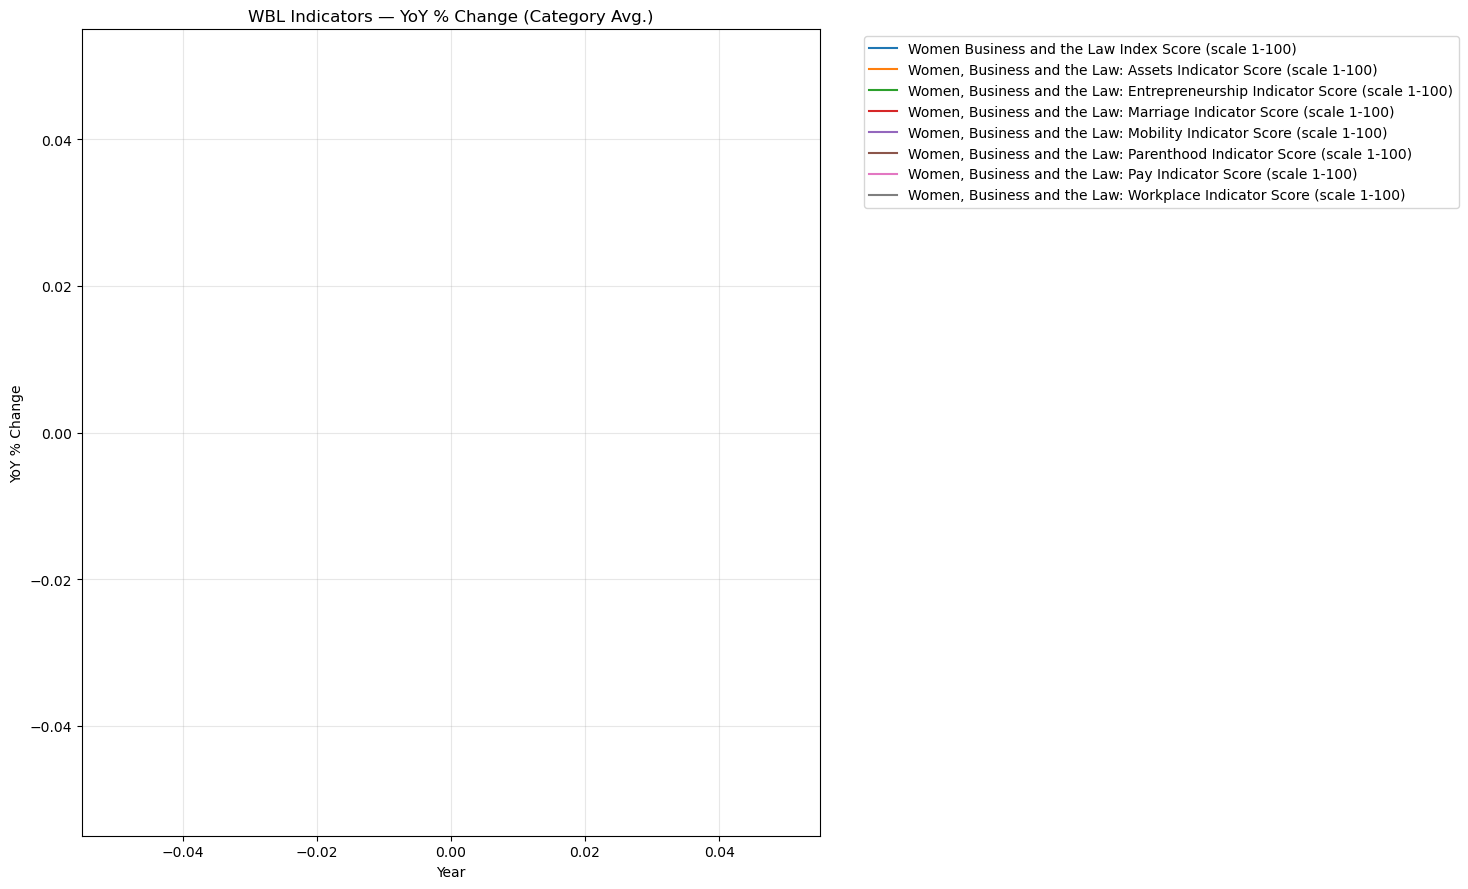

In [43]:
plt.figure(figsize=(15, 9))

for ind in indicators:
    temp = wbl_df[wbl_df["indicator_name"] == ind]
    yearly = temp.groupby("year")["yoy_pct_change"].mean().reset_index()
    plt.plot(yearly["year"], yearly["yoy_pct_change"], label=ind)

plt.title("WBL Indicators — YoY % Change (Category Avg.)")
plt.xlabel("Year")
plt.ylabel("YoY % Change")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### PLOT SET 4 — Spike & Dip Frequency per Indicator

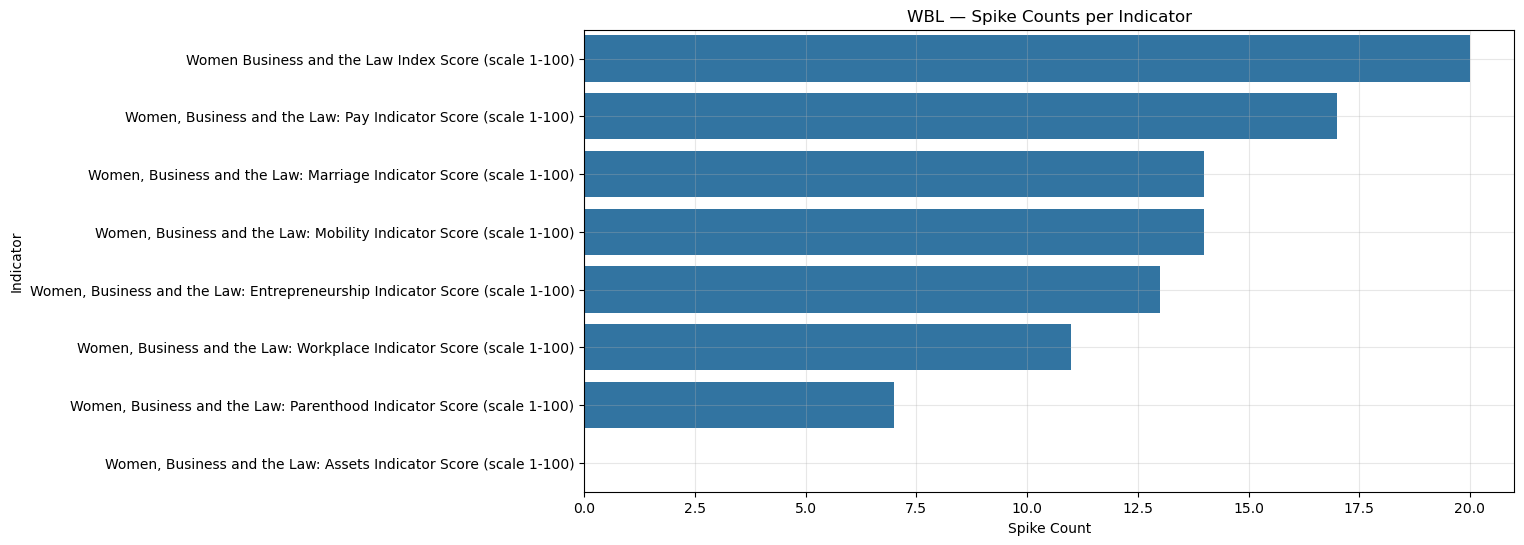

In [44]:
spike_counts = (
    wbl_df.groupby("indicator_name")["spike"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=spike_counts.values, y=spike_counts.index)
plt.title("WBL — Spike Counts per Indicator")
plt.xlabel("Spike Count")
plt.ylabel("Indicator")
plt.grid(alpha=0.3)
plt.show()


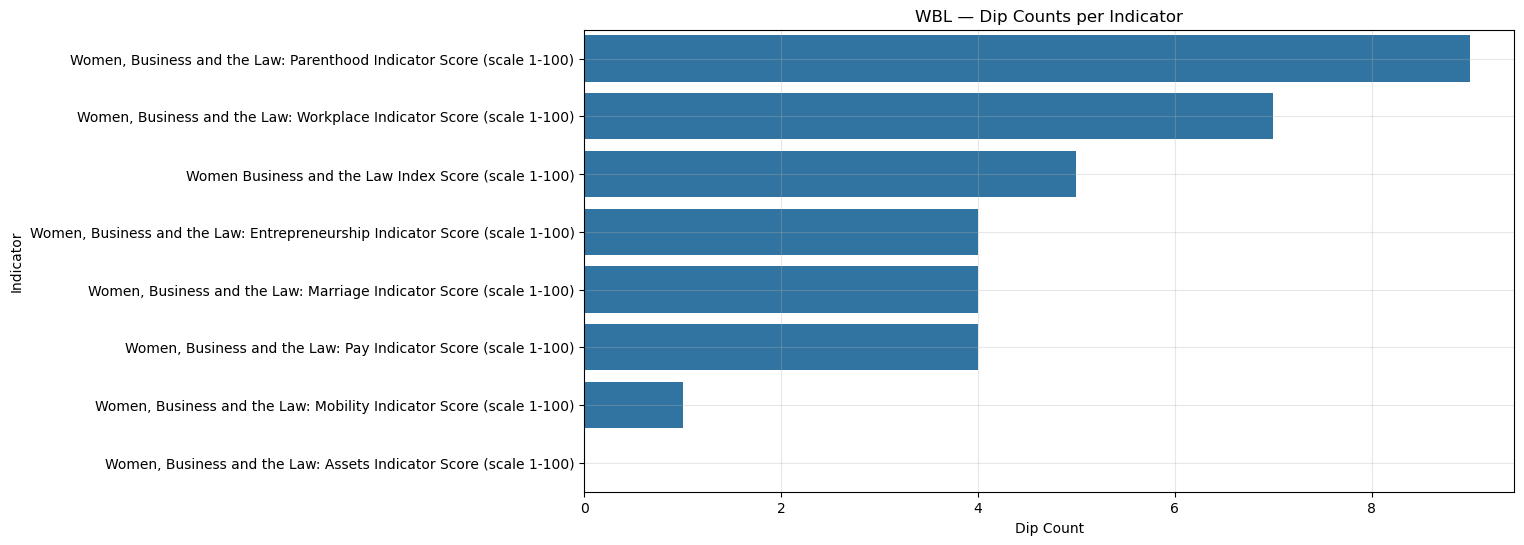

In [45]:
dip_counts = (
    wbl_df.groupby("indicator_name")["dip"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=dip_counts.values, y=dip_counts.index)
plt.title("WBL — Dip Counts per Indicator")
plt.xlabel("Dip Count")
plt.ylabel("Indicator")
plt.grid(alpha=0.3)
plt.show()


#### (1) COUNTRY-LEVEL WBL SCORE OVER TIME

This shows the average WBL value per country, which tells you:

who is improving

who is flat

who is volatile

structural reforms

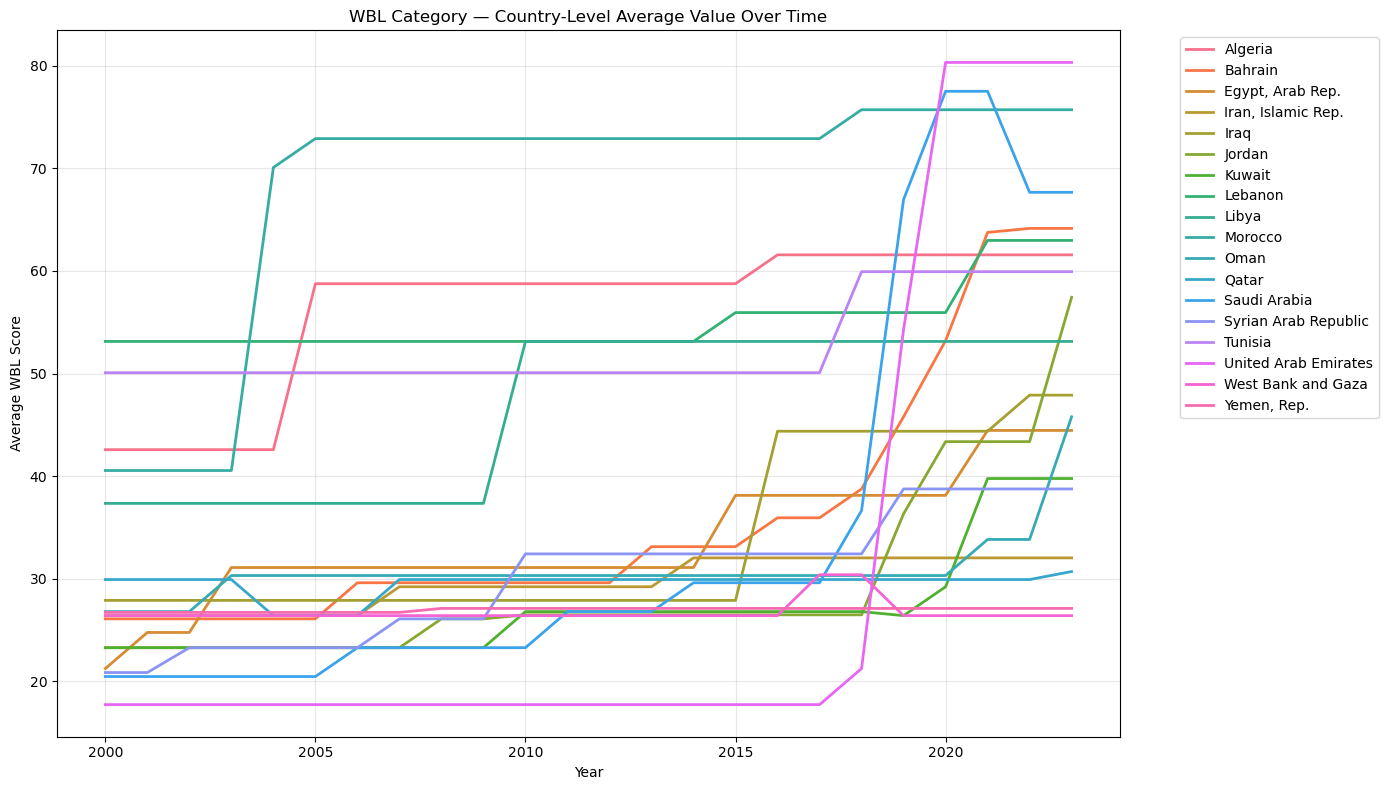

In [47]:
plt.figure(figsize=(14, 8))

country_trends = (
    wbl_df.groupby(["country_name", "year"])["val_num"]
    .mean()
    .reset_index()
)

sns.lineplot(
    data=country_trends,
    x="year", y="val_num",
    hue="country_name",
    linewidth=2
)

plt.title("WBL Category — Country-Level Average Value Over Time")
plt.ylabel("Average WBL Score")
plt.xlabel("Year")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### (2) COUNTRY-LEVEL VOLATILITY (Rolling Std)

This answers:

Which countries frequently change laws

Which countries are legally “stable”

Who reacts most during shocks (Arab Spring, etc.)

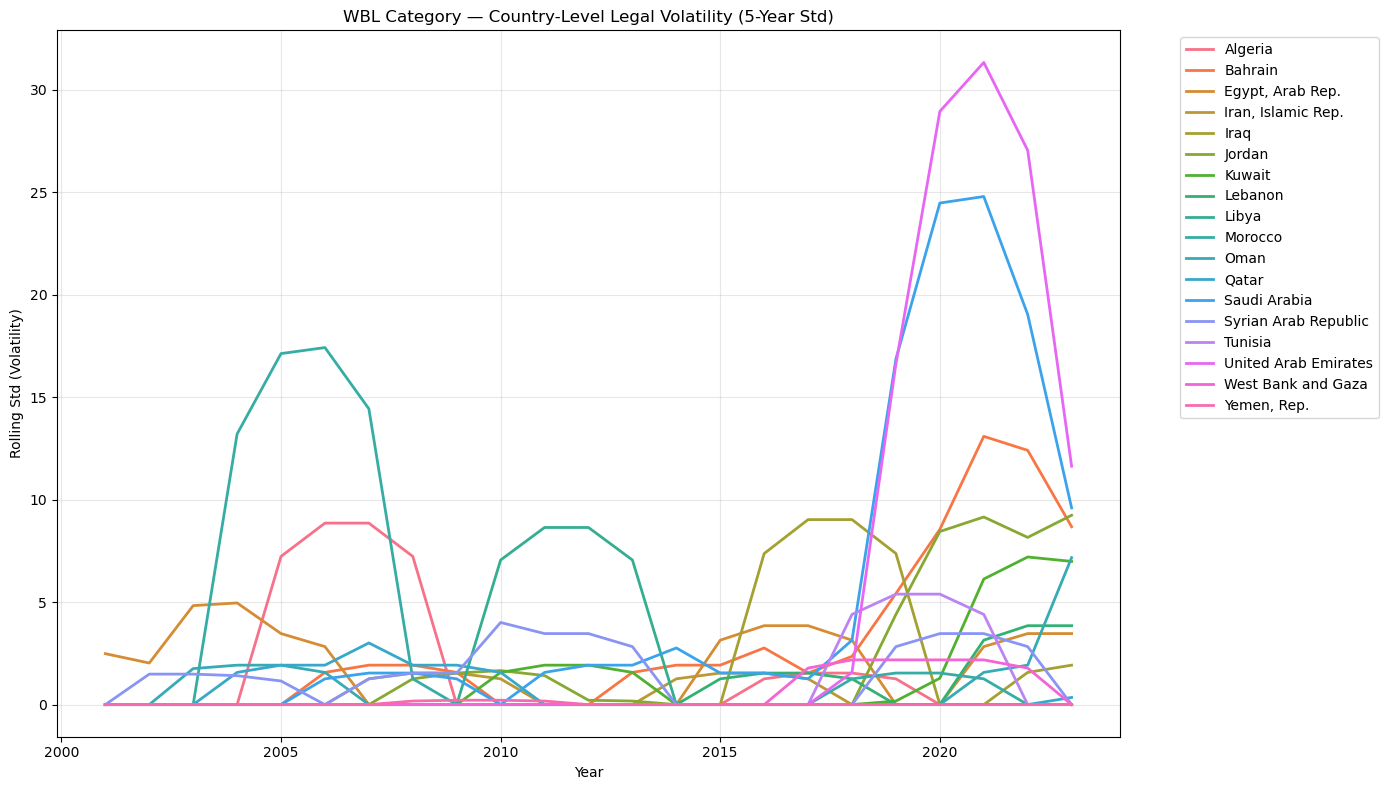

In [48]:
plt.figure(figsize=(14, 8))

vol = (
    wbl_df.groupby(["country_name", "year"])["rolling_std_5y"]
    .mean()
    .reset_index()
)

sns.lineplot(
    data=vol,
    x="year", y="rolling_std_5y",
    hue="country_name",
    linewidth=2
)

plt.title("WBL Category — Country-Level Legal Volatility (5-Year Std)")
plt.ylabel("Rolling Std (Volatility)")
plt.xlabel("Year")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### (3) COUNTRY-LEVEL YoY % CHANGE

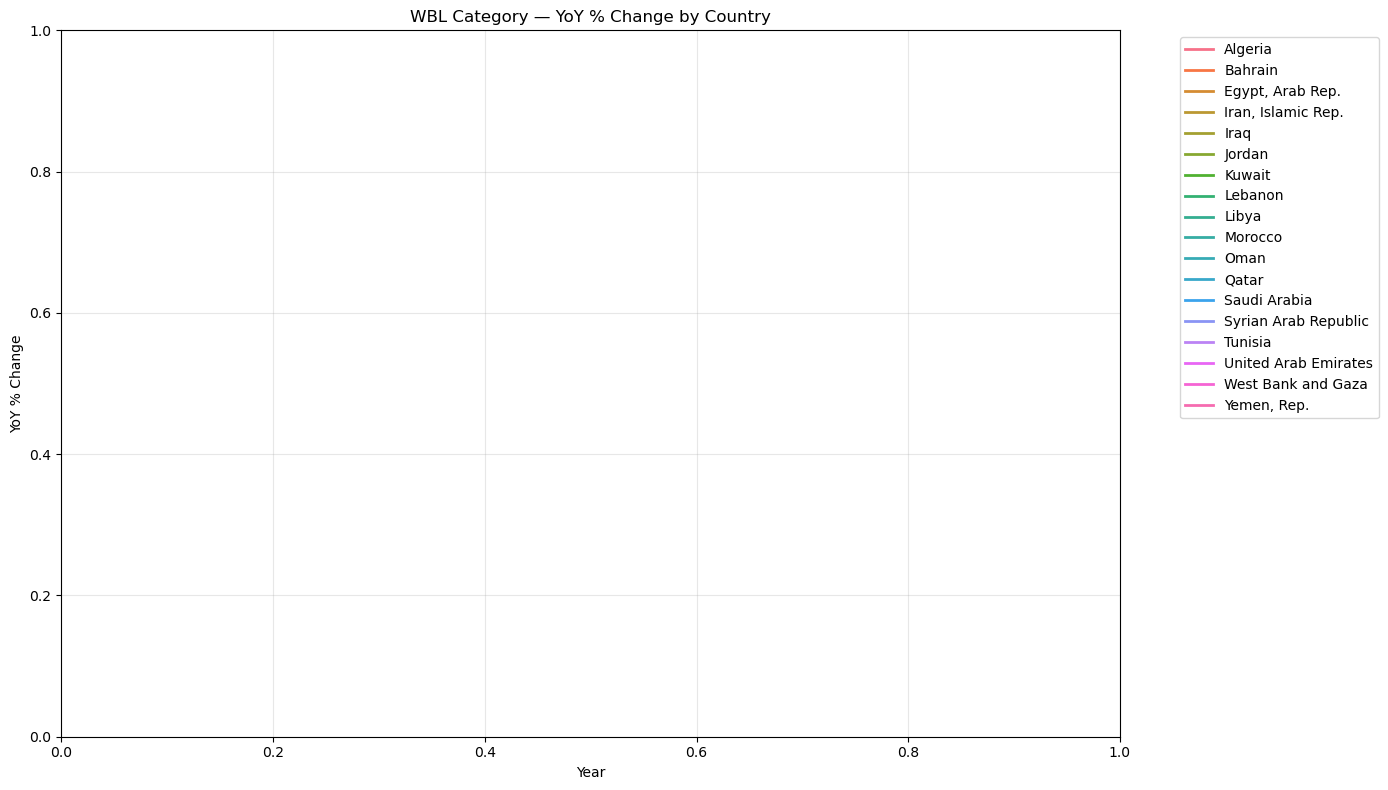

In [49]:
plt.figure(figsize=(14, 8))

yoy = (
    wbl_df.groupby(["country_name", "year"])["yoy_pct_change"]
    .mean()
    .reset_index()
)

sns.lineplot(
    data=yoy,
    x="year", y="yoy_pct_change",
    hue="country_name",
    linewidth=2
)

plt.title("WBL Category — YoY % Change by Country")
plt.ylabel("YoY % Change")
plt.xlabel("Year")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


#### (4) SPIKE & DIP FREQUENCY BY COUNTRY

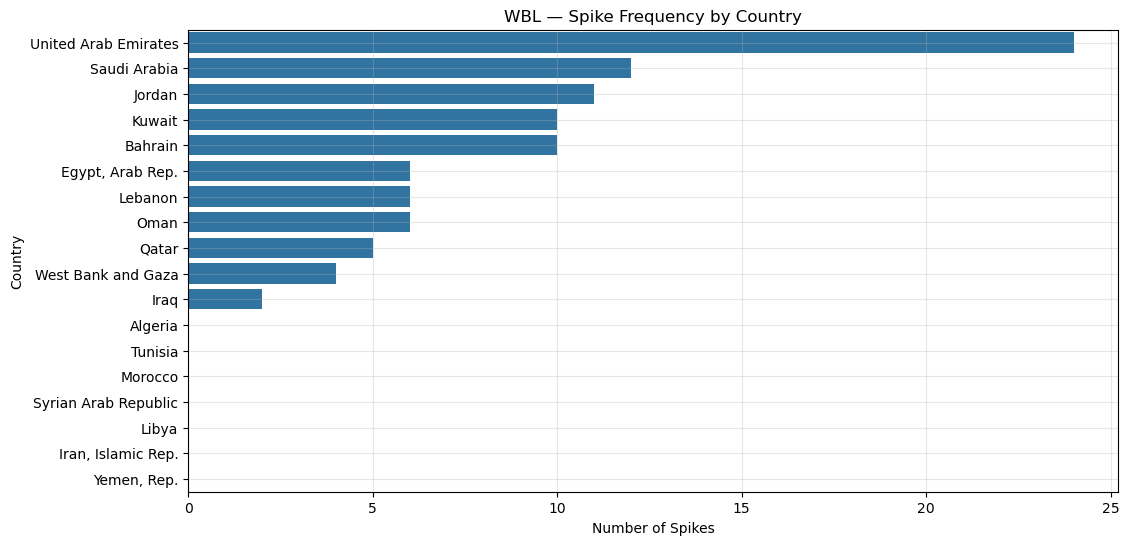

In [50]:
spike_counts = (
    wbl_df.groupby("country_name")["spike"].sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(y=spike_counts.index, x=spike_counts.values)
plt.title("WBL — Spike Frequency by Country")
plt.xlabel("Number of Spikes")
plt.ylabel("Country")
plt.grid(alpha=0.3)
plt.show()


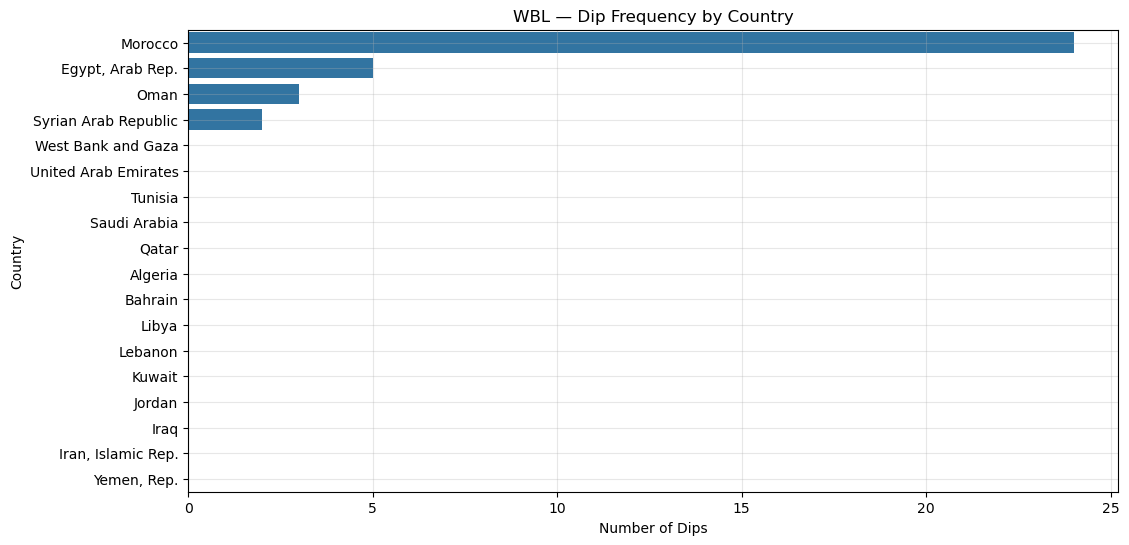

In [51]:
dip_counts = (
    wbl_df.groupby("country_name")["dip"].sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(y=dip_counts.index, x=dip_counts.values)
plt.title("WBL — Dip Frequency by Country")
plt.xlabel("Number of Dips")
plt.ylabel("Country")
plt.grid(alpha=0.3)
plt.show()


#### (5) RADAR CHART — COUNTRY WBL PROFILE (Average)

Shows which countries score high/low across all WBL indicators.

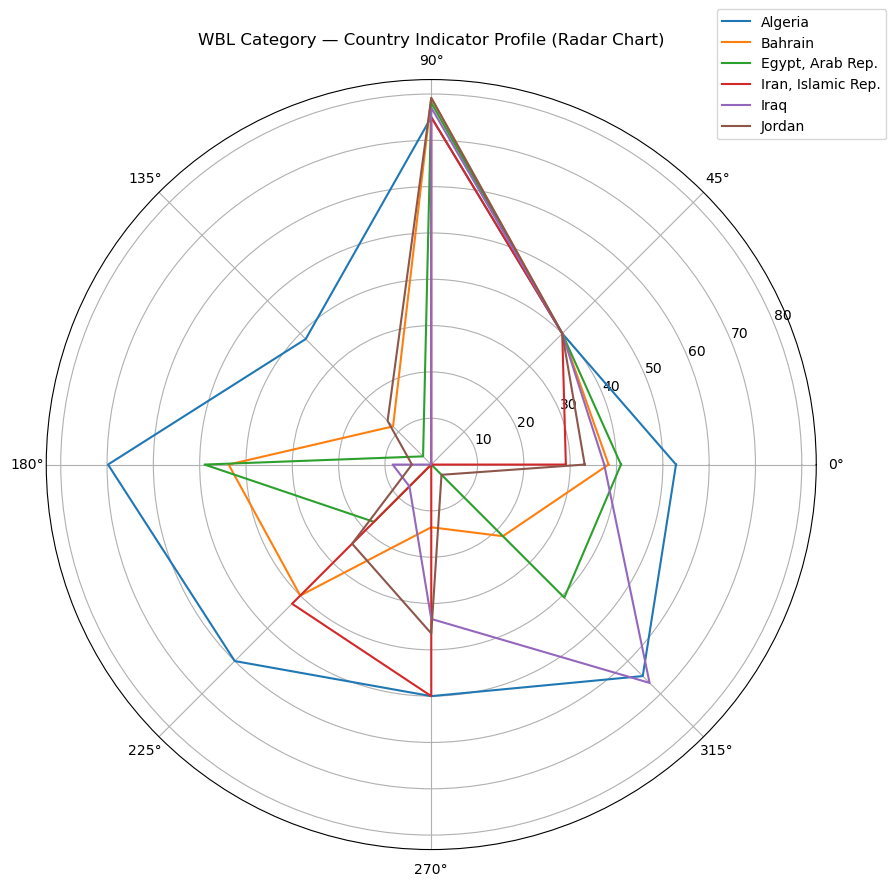

In [52]:
import numpy as np

pivot_wbl = (
    wbl_df.groupby(["country_name", "indicator_name"])["val_num"]
    .mean()
    .unstack()
)

# Choose top 6 countries for clarity
countries = pivot_wbl.index[:6]
indicators = pivot_wbl.columns

angles = np.linspace(0, 2*np.pi, len(indicators), endpoint=False).tolist()
angles += angles[:1]  # close loop

plt.figure(figsize=(10, 10))

for country in countries:
    values = pivot_wbl.loc[country].values.tolist()
    values += values[:1]
    plt.polar(angles, values, label=country)

plt.title("WBL Category — Country Indicator Profile (Radar Chart)")
plt.legend(bbox_to_anchor=(1.1, 1.1))
plt.show()


## Examining the Other Features

In [53]:
ind = fe_df[fe_df["indicator_name"] == 
            "Adolescent fertility rate (births per 1,000 women ages 15-19)"]


In [54]:
ind.groupby("country_name").size()


country_name
Algeria                 24
Bahrain                 24
Egypt, Arab Rep.        24
Iran, Islamic Rep.      24
Iraq                    24
Jordan                  24
Kuwait                  24
Lebanon                 24
Libya                   24
Morocco                 24
Oman                    24
Qatar                   24
Saudi Arabia            24
Syrian Arab Republic    24
Tunisia                 24
United Arab Emirates    24
West Bank and Gaza      24
Yemen, Rep.             24
dtype: int64

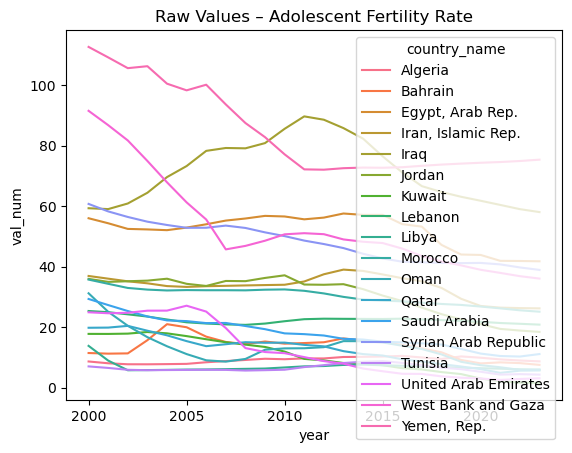

In [55]:
sns.lineplot(data=ind, x="year", y="val_num", hue="country_name")
plt.title("Raw Values – Adolescent Fertility Rate")
plt.show()


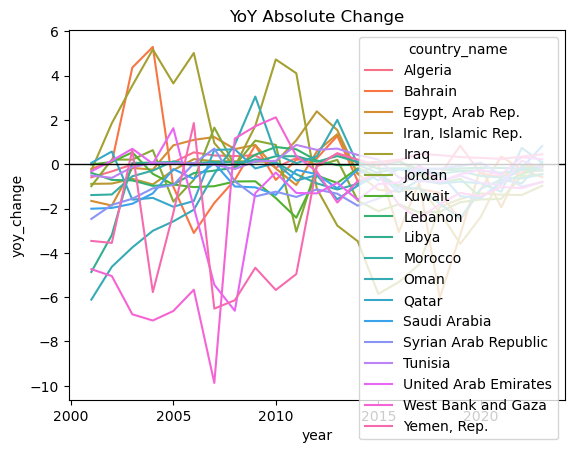

In [56]:
sns.lineplot(data=ind, x="year", y="yoy_change", hue="country_name")
plt.title("YoY Absolute Change")
plt.axhline(0, color="black", linewidth=1)
plt.show()


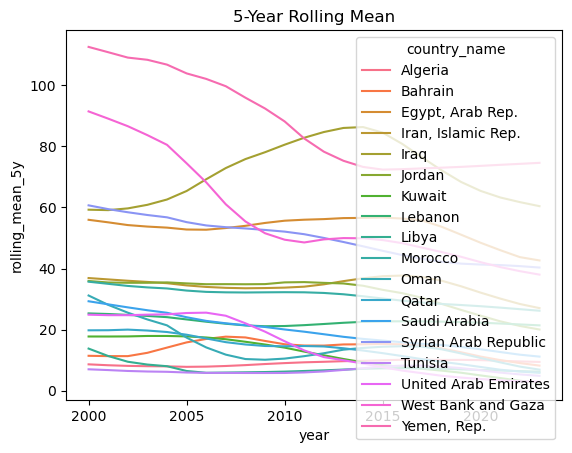

In [57]:
sns.lineplot(data=ind, x="year", y="rolling_mean_5y", hue="country_name")
plt.title("5-Year Rolling Mean")
plt.show()


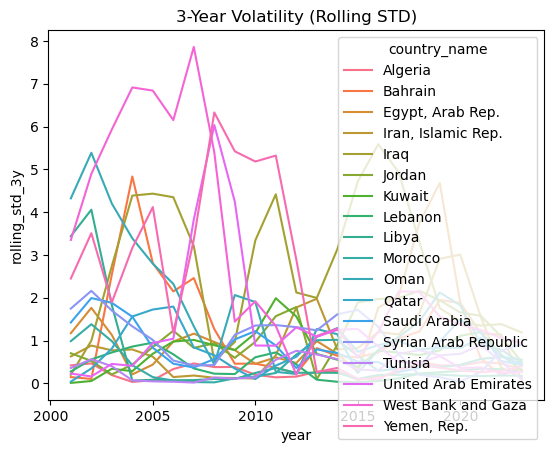

In [58]:
sns.lineplot(data=ind, x="year", y="rolling_std_3y", hue="country_name")
plt.title("3-Year Volatility (Rolling STD)")
plt.show()


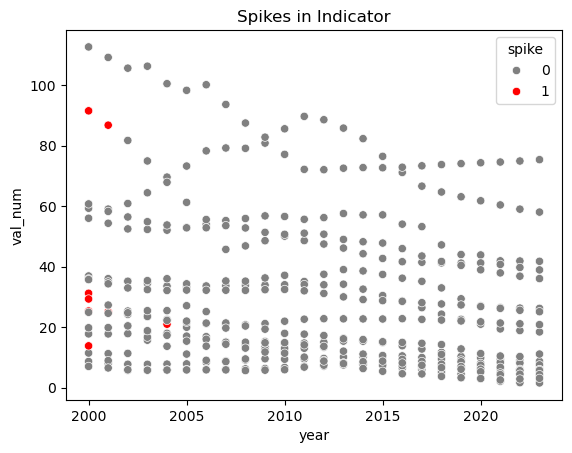

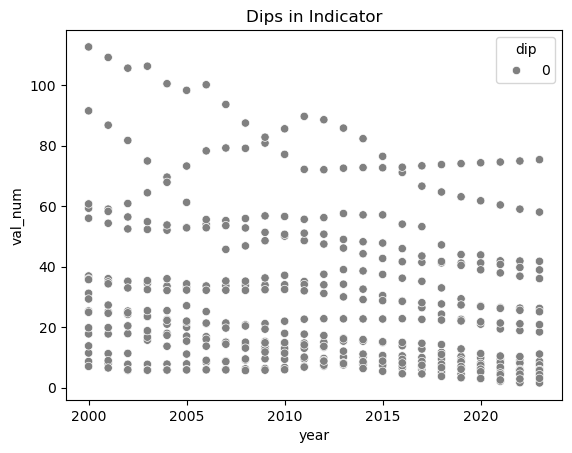

In [59]:
sns.scatterplot(data=ind, x="year", y="val_num",
                hue="spike", palette={1:"red",0:"grey"})
plt.title("Spikes in Indicator")
plt.show()

sns.scatterplot(data=ind, x="year", y="val_num",
                hue="dip", palette={1:"blue",0:"grey"})
plt.title("Dips in Indicator")
plt.show()


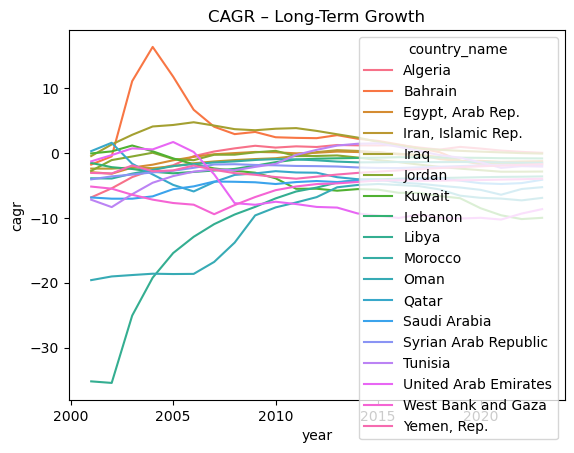

In [60]:
sns.lineplot(data=ind, x="year", y="cagr", hue="country_name")
plt.title("CAGR – Long-Term Growth")
plt.show()


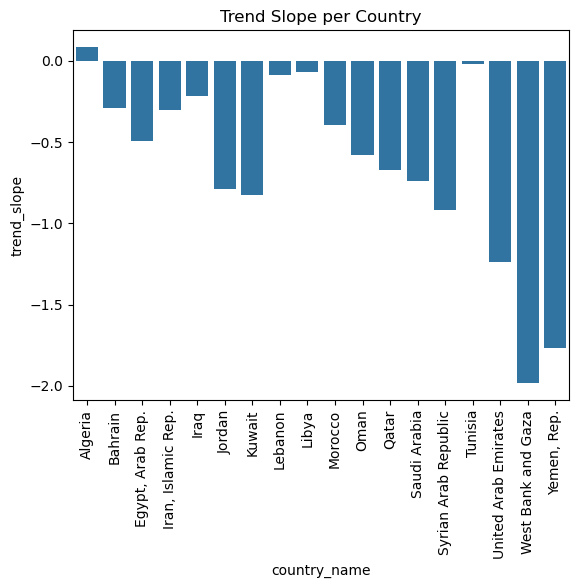

In [61]:
sns.barplot(data=ind, x="country_name", y="trend_slope")
plt.xticks(rotation=90)
plt.title("Trend Slope per Country")
plt.show()


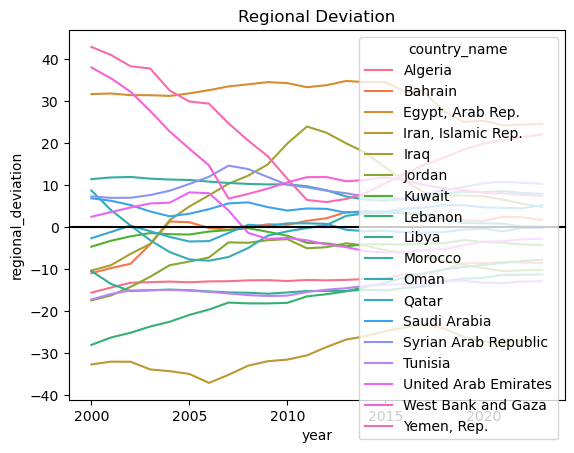

In [62]:
sns.lineplot(data=ind, x="year", y="regional_deviation", hue="country_name")
plt.title("Regional Deviation")
plt.axhline(0, color="black")
plt.show()


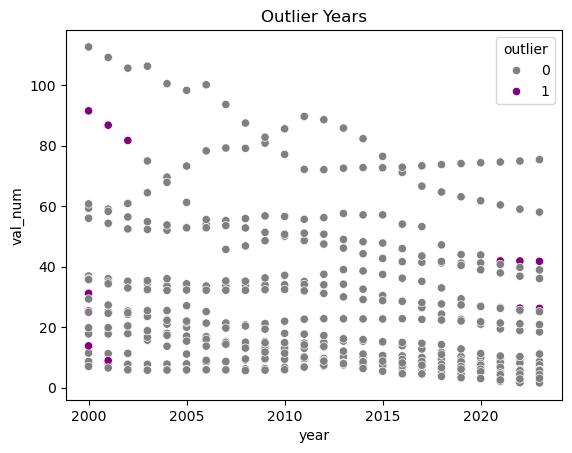

In [63]:
sns.scatterplot(data=ind, x="year", y="val_num",
                hue="outlier", palette={1:"purple",0:"grey"})
plt.title("Outlier Years")
plt.show()


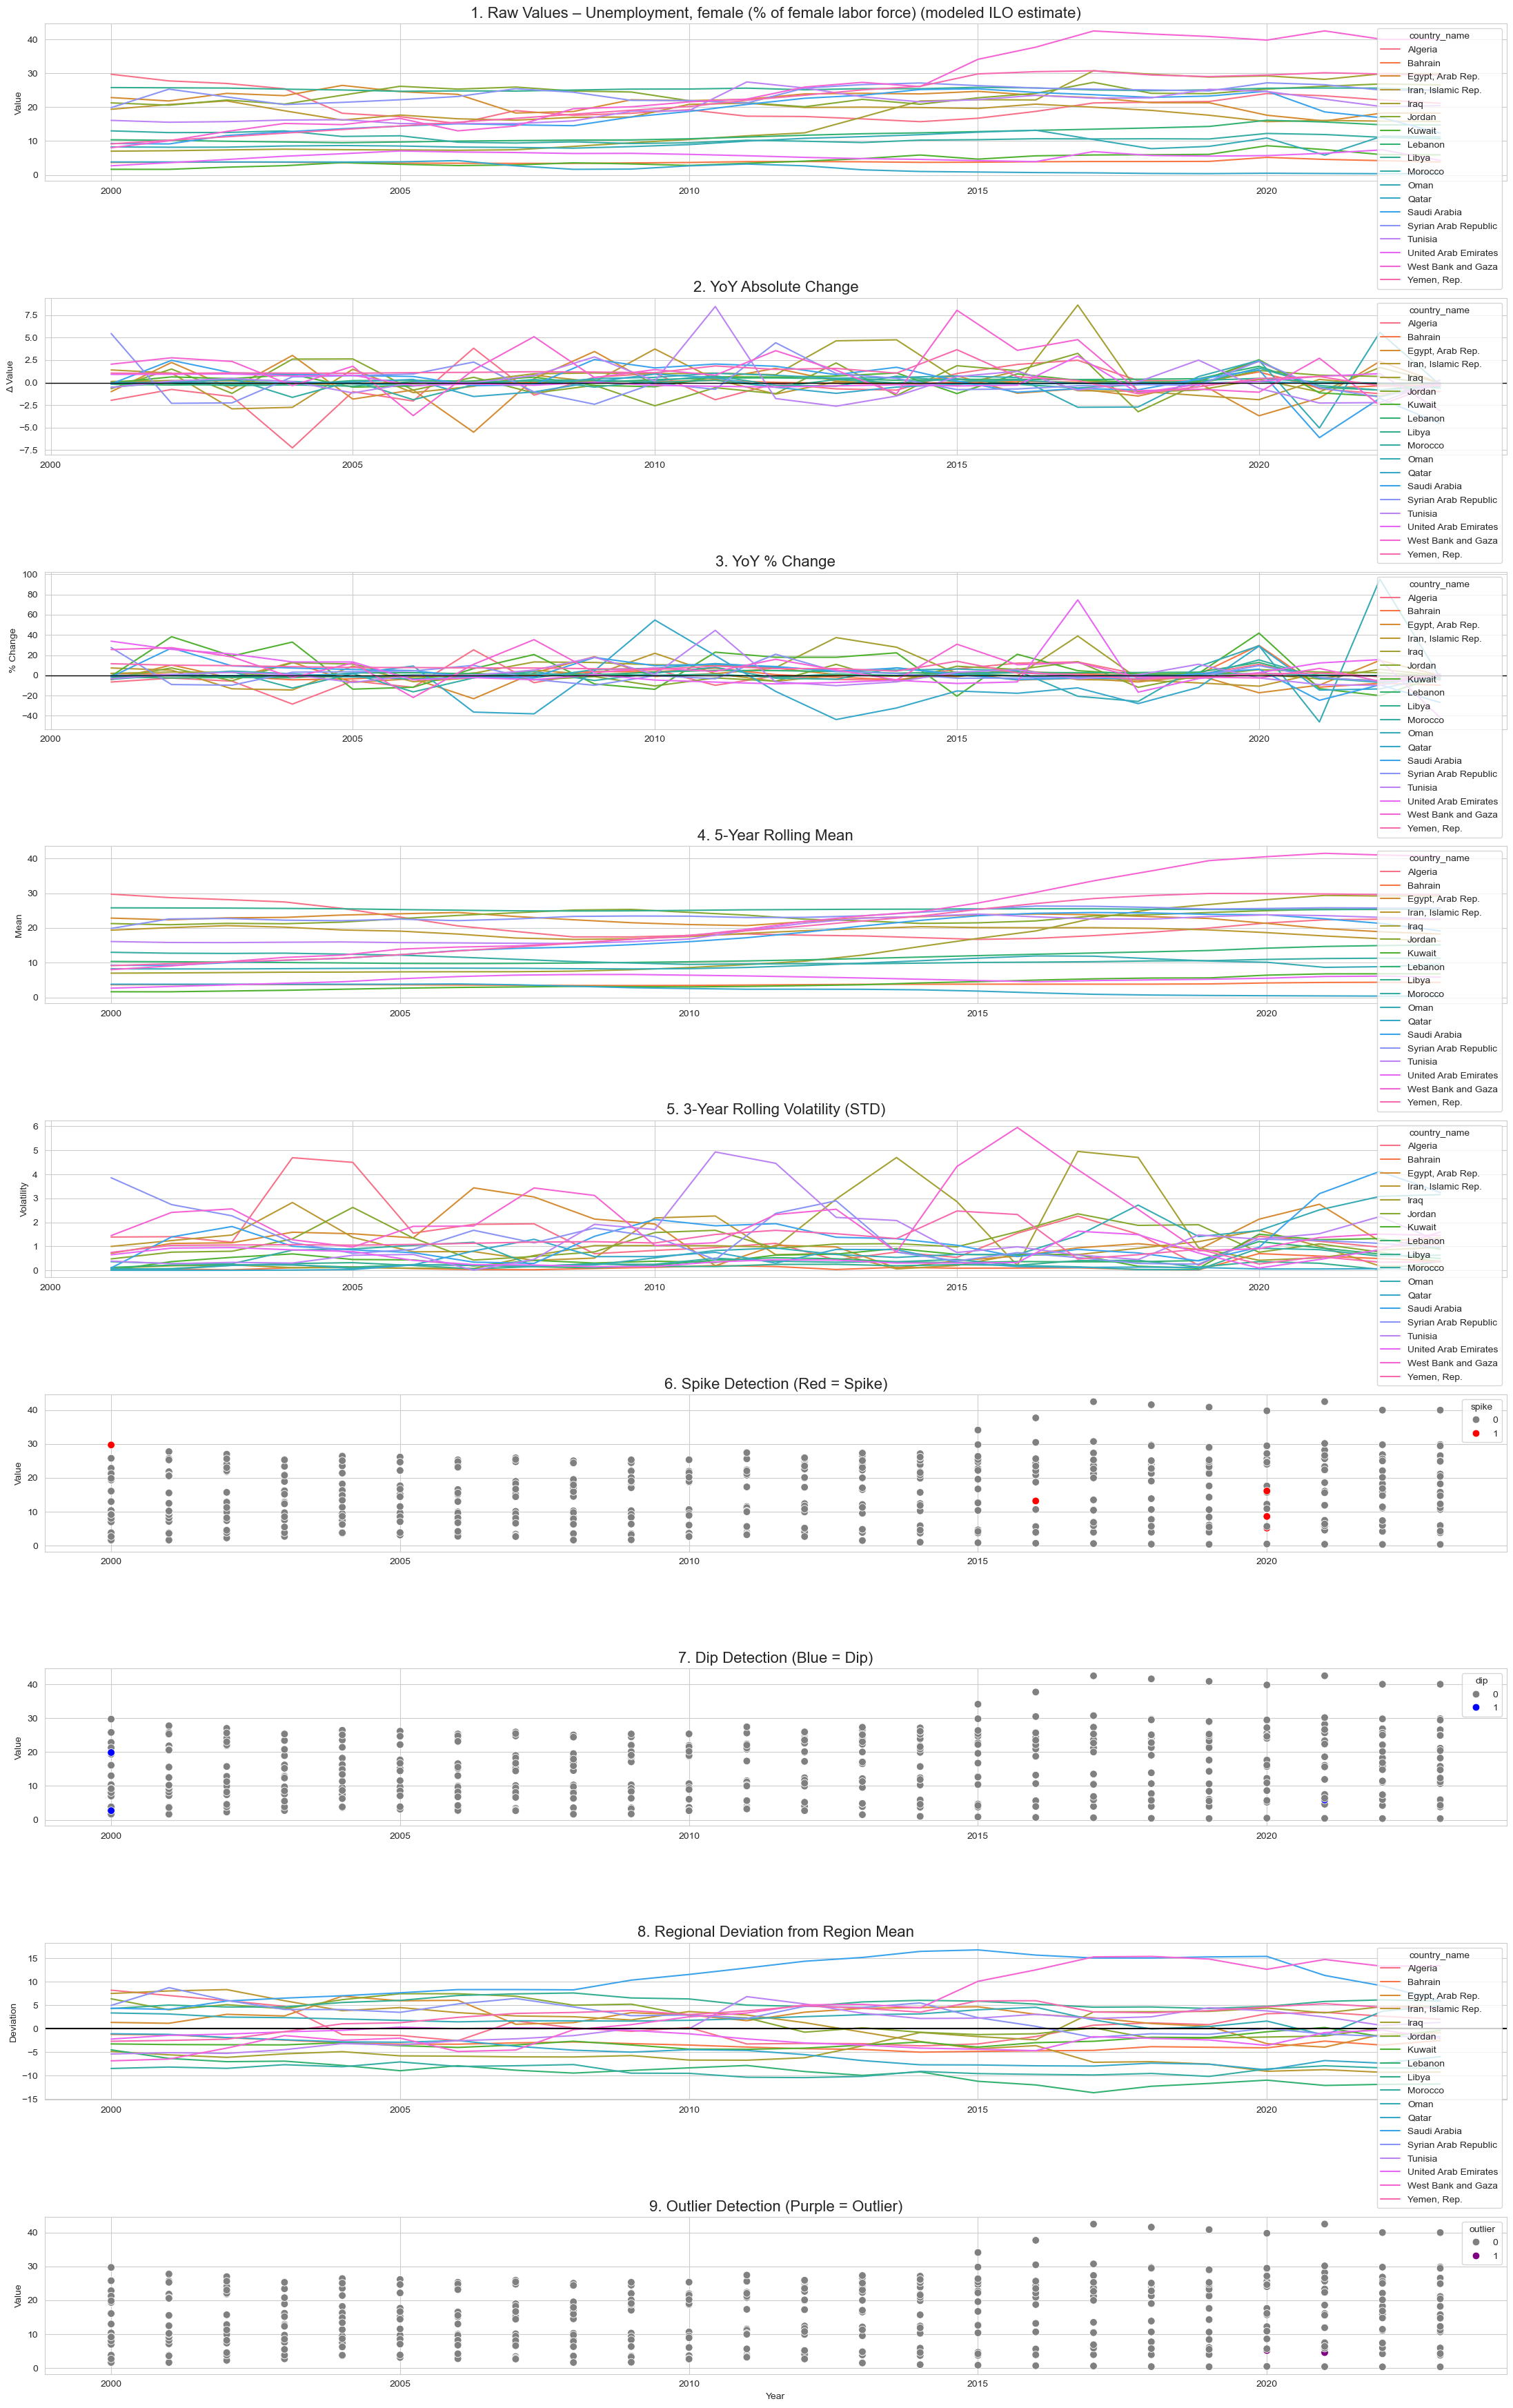

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# ========= SELECT INDICATOR =========
indicator_to_plot = "Unemployment, female (% of female labor force) (modeled ILO estimate)"

# ========= FILTER DATA =========
ind = fe_df[fe_df["indicator_name"] == indicator_to_plot].copy()
ind = ind.sort_values(["country_name", "year"])

plt.figure(figsize=(22, 35))
sns.set_style("whitegrid")

# -------------------------------------------------------------
# 1. Raw Values
plt.subplot(9, 1, 1)
sns.lineplot(data=ind, x="year", y="val_num", hue="country_name")
plt.title(f"1. Raw Values – {indicator_to_plot}", fontsize=16)
plt.xlabel(""); plt.ylabel("Value")

# -------------------------------------------------------------
# 2. YoY Absolute Change
plt.subplot(9, 1, 2)
sns.lineplot(data=ind, x="year", y="yoy_change", hue="country_name")
plt.axhline(0, color="black", linewidth=1)
plt.title("2. YoY Absolute Change", fontsize=16)
plt.xlabel(""); plt.ylabel("Δ Value")

# -------------------------------------------------------------
# 3. YoY % Change
plt.subplot(9, 1, 3)
sns.lineplot(data=ind, x="year", y="yoy_pct_change", hue="country_name")
plt.axhline(0, color="black", linewidth=1)
plt.title("3. YoY % Change", fontsize=16)
plt.xlabel(""); plt.ylabel("% Change")

# -------------------------------------------------------------
# 4. Rolling Mean (5-year)
plt.subplot(9, 1, 4)
sns.lineplot(data=ind, x="year", y="rolling_mean_5y", hue="country_name")
plt.title("4. 5-Year Rolling Mean", fontsize=16)
plt.xlabel(""); plt.ylabel("Mean")

# -------------------------------------------------------------
# 5. Rolling STD (3-year volatility)
plt.subplot(9, 1, 5)
sns.lineplot(data=ind, x="year", y="rolling_std_3y", hue="country_name")
plt.title("5. 3-Year Rolling Volatility (STD)", fontsize=16)
plt.xlabel(""); plt.ylabel("Volatility")

# -------------------------------------------------------------
# 6. Spikes
plt.subplot(9, 1, 6)
sns.scatterplot(data=ind, x="year", y="val_num",
                hue="spike", palette={1:"red",0:"grey"}, s=60)
plt.title("6. Spike Detection (Red = Spike)", fontsize=16)
plt.xlabel(""); plt.ylabel("Value")

# -------------------------------------------------------------
# 7. Dips
plt.subplot(9, 1, 7)
sns.scatterplot(data=ind, x="year", y="val_num",
                hue="dip", palette={1:"blue",0:"grey"}, s=60)
plt.title("7. Dip Detection (Blue = Dip)", fontsize=16)
plt.xlabel(""); plt.ylabel("Value")

# -------------------------------------------------------------
# 8. Regional Deviation
plt.subplot(9, 1, 8)
sns.lineplot(data=ind, x="year", y="regional_deviation", hue="country_name")
plt.axhline(0, color="black")
plt.title("8. Regional Deviation from Region Mean", fontsize=16)
plt.xlabel(""); plt.ylabel("Deviation")

# -------------------------------------------------------------
# 9. Outliers
plt.subplot(9, 1, 9)
sns.scatterplot(data=ind, x="year", y="val_num",
                hue="outlier", palette={1:"purple",0:"grey"}, s=60)
plt.title("9. Outlier Detection (Purple = Outlier)", fontsize=16)
plt.xlabel("Year"); plt.ylabel("Value")

plt.tight_layout()
plt.show()
